# Router Multi-Agent Playground (LangGraph)

This notebook prototypes a **router multi-agent pattern** on top of the existing
`AccountantAgent` and `InventoryAgent` runtimes.

A small LLM **router node** classifies the incoming user message and dispatches
it to the most appropriate specialist subagent. Each specialist is the same
runtime used in production (`services/agent/app/runtime/...`), so behavior here
matches what the chat endpoint would do once routing is wired in.

## Architecture

```mermaid
graph TD
    User[User Message] --> Router["router_node (LLM classifier)"]
    Router -->|accountant| Acc["accountant_node (AccountantAgent runtime)"]
    Router -->|inventory| Inv["inventory_node (InventoryAgent runtime)"]
    Router -->|experimental| Exp["experimental_node (separate experimental notebook graph)"]
    Router -->|general| Gen["general_node (direct LLM)"]
    Acc --> End[END]
    Inv --> End
    Exp --> End
    Gen --> End
```

## What this notebook gives you

1. A working LangGraph `StateGraph` that picks between specialists per turn.
2. Streaming token output from the chosen subagent.
3. A trace of which route was taken and why.
4. A separate experimental graph notebook that can be invoked through the router.
5. A small evaluation harness so you can tune the router prompt against a
   labelled set of queries.

Run cells top-to-bottom. The first cell may force a kernel restart the first
time you open the notebook, just like `accountant_agent_playground.ipynb`.

In [72]:
from __future__ import annotations

import importlib
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

ROOT = Path.cwd().resolve()
REPO_ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
AGENT_SERVICE_ROOT = REPO_ROOT / "services" / "agent"
AGENT_REQUIREMENTS = AGENT_SERVICE_ROOT / "requirements.txt"

if str(AGENT_SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(AGENT_SERVICE_ROOT))


def _parse_major_minor(ver: str) -> tuple[int, int]:
    parts = ver.split(".")
    major = int(parts[0]) if parts and parts[0].isdigit() else 0
    minor = int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else 0
    return major, minor


def _pip(args: list[str], *, check: bool = True) -> subprocess.CompletedProcess[str]:
    cmd = [sys.executable, "-m", "pip", "--disable-pip-version-check", *args]
    return subprocess.run(cmd, capture_output=True, text=True, check=check)


def _agent_runtime_needs_sync() -> bool:
    minimums: dict[str, tuple[int, int]] = {
        "pydantic": (2, 9),
        "pydantic-settings": (2, 6),
        "pymongo": (4, 9),
        "motor": (3, 6),
        "httpx": (0, 28),
        "langchain": (0, 3),
        "langchain-core": (0, 3),
        "langchain-openai": (0, 2),
        "langchain-anthropic": (0, 3),
    }
    for package, (min_major, min_minor) in minimums.items():
        try:
            current = version(package)
        except PackageNotFoundError:
            return True
        if _parse_major_minor(current) < (min_major, min_minor):
            return True
    for mod_name in ("email_validator", "bson"):
        try:
            importlib.import_module(mod_name)
        except ImportError:
            return True
    return False


def _router_extras_needed() -> list[str]:
    """Packages this notebook needs on top of the agent runtime requirements."""
    extras: list[str] = []
    try:
        lg_ver = version("langgraph")
        if _parse_major_minor(lg_ver) < (0, 2):
            extras.append("langgraph>=0.2,<1.0")
    except PackageNotFoundError:
        extras.append("langgraph>=0.2,<1.0")

    try:
        importlib.import_module("nest_asyncio")
    except ImportError:
        extras.append("nest-asyncio>=1.6.0")

    try:
        importlib.import_module("grandalf")
    except ImportError:
        extras.append("grandalf>=0.8")
    return extras


def ensure_dependencies() -> bool:
    """Return True when a kernel restart is required."""
    if not AGENT_REQUIREMENTS.exists():
        raise FileNotFoundError(f"Requirements file not found: {AGENT_REQUIREMENTS}")

    restart_required = False

    if _agent_runtime_needs_sync():
        print("Aligning notebook kernel with agent service requirements...")
        _pip(["install", "--upgrade", "-r", str(AGENT_REQUIREMENTS)], check=True)
        restart_required = True

    extras = _router_extras_needed()
    if extras:
        print(f"Installing router-notebook extras: {extras}")
        _pip(["install", "--upgrade", *extras], check=True)
        restart_required = True

    if not restart_required:
        print("Notebook kernel already aligned with router-notebook requirements.")
    else:
        print("\nDependencies updated. Restart the Jupyter kernel and rerun from cell 1.")
    return restart_required


RESTART_REQUIRED = ensure_dependencies()

X_USER_ID = globals().get("X_USER_ID", "69ee3344826015e6593e6c9e")
ACCOUNTANT_AGENT_ID = globals().get("ACCOUNTANT_AGENT_ID", "69ee334437c7ac857d865c8d")
INVENTORY_AGENT_ID = globals().get("INVENTORY_AGENT_ID", "69f93225cb672064c4886a7b")
ROUTER_PROVIDER = globals().get("ROUTER_PROVIDER", "openai")
ROUTER_MODEL = globals().get("ROUTER_MODEL", "gpt-4.1-mini")
ROUTER_TEMPERATURE = float(globals().get("ROUTER_TEMPERATURE", 0.0))

if RESTART_REQUIRED:
    print("\nSetup paused until kernel restart.")
else:
    from app.config import settings

    if "localhost" not in settings.mongodb_url and "127.0.0.1" not in settings.mongodb_url:
        settings.mongodb_url = "mongodb://localhost:27017"
    if "localhost" not in settings.business_service_url and "127.0.0.1" not in settings.business_service_url:
        settings.business_service_url = "http://localhost:8005"
    if "localhost" not in settings.knowledge_service_url and "127.0.0.1" not in settings.knowledge_service_url:
        settings.knowledge_service_url = "http://localhost:8003"

    print(f"Repo root: {REPO_ROOT}")
    print(f"Agent service root: {AGENT_SERVICE_ROOT}")
    print(f"Mongo URL:     {settings.mongodb_url}")
    print(f"Business URL:  {settings.business_service_url}")
    print(f"Knowledge URL: {settings.knowledge_service_url}")
    print(f"Router LLM:    provider={ROUTER_PROVIDER} model={ROUTER_MODEL} temp={ROUTER_TEMPERATURE}")


Notebook kernel already aligned with router-notebook requirements.
Repo root: /Users/valentinbarakov/proecti/agents
Agent service root: /Users/valentinbarakov/proecti/agents/services/agent
Mongo URL:     mongodb://localhost:27017
Business URL:  http://localhost:8005
Knowledge URL: http://localhost:8003
Router LLM:    provider=openai model=gpt-4.1-mini temp=0.0


## 1) Configuration

Set the user and the agent IDs (one per agent type) that the router can dispatch
to. Each subagent inherits its tool surface from its `AgentInDB` record in
MongoDB, exactly like in production.

If you do not have an Inventory agent yet, leave `INVENTORY_AGENT_ID` empty and
the inventory branch will be unavailable (the router will fall back to
`general` when it picks `inventory`).

In [73]:
# Edit these freely between runs; they re-export to globals so subsequent
# cells pick them up. Keep ROUTER_TEMPERATURE at 0 unless you are deliberately
# probing routing variance.

X_USER_ID = "69ee3344826015e6593e6c9e"
ACCOUNTANT_AGENT_ID = "69ee334437c7ac857d865c8d"
INVENTORY_AGENT_ID = "69f93225cb672064c4886a7b"

ROUTER_PROVIDER = "openai"
ROUTER_MODEL = "gpt-4.1-mini"
ROUTER_TEMPERATURE = 0.0

print(
    f"user_id={X_USER_ID}\n"
    f"accountant_agent_id={ACCOUNTANT_AGENT_ID}\n"
    f"inventory_agent_id={INVENTORY_AGENT_ID or '(disabled)'}\n"
    f"router={ROUTER_PROVIDER}/{ROUTER_MODEL} temp={ROUTER_TEMPERATURE}"
)


user_id=69ee3344826015e6593e6c9e
accountant_agent_id=69ee334437c7ac857d865c8d
inventory_agent_id=69f93225cb672064c4886a7b
router=openai/gpt-4.1-mini temp=0.0


## 2) Specialist runtime factory

Helper that loads an `AgentInDB` from MongoDB and instantiates the matching
runtime (`AccountantAgent` or `InventoryAgent`). The returned object is the
same `BaseAgent` used by `services/agent/app/services/chat_service.py`, so any
prompt / tool change in the runtime files is picked up here automatically.

We also define a single shared `ToolContext` per session — the underlying
`httpx.AsyncClient`s are reused across both subagents to avoid leaking
connections.

In [74]:
if RESTART_REQUIRED:
    raise RuntimeError(
        "Restart the kernel and rerun from cell 1 before continuing. "
        "The dependency setup cell installed packages that aren't visible to this kernel yet."
    )

from dataclasses import dataclass

import httpx

from app.clients.business import BusinessClient
from app.config import settings
from app.models.shared.agent import AgentInDB
from app.models.shared.conversation import MessageSchema
from app.repositories.agent_repo import AgentRepository
from app.runtime.accountant import AccountantAgent
from app.runtime.base_agent import BaseAgent
from app.runtime.inventory import InventoryAgent
from app.runtime.providers.factory import LLMProviderFactory
from app.runtime.tool_context import ToolContext
from app.services.companybook_service import CompanyBookService
from app.utils.db import close_db, connect_db, get_database


@dataclass
class RouterSession:
    """Owns the long-lived clients/tool_context for one playground session."""

    business_http: httpx.AsyncClient
    knowledge_http: httpx.AsyncClient
    tool_context: ToolContext

    async def aclose(self) -> None:
        await self.business_http.aclose()
        await self.knowledge_http.aclose()


def open_router_session() -> RouterSession:
    business_http = httpx.AsyncClient(
        base_url=settings.business_service_url,
        timeout=settings.business_timeout_seconds,
    )
    knowledge_http = httpx.AsyncClient(
        base_url=settings.knowledge_service_url,
        timeout=settings.knowledge_timeout_seconds,
    )
    tool_context = ToolContext(
        business_client=BusinessClient(business_http),
        companybook_service=CompanyBookService(
            api_key=settings.companybook_api_key,
            base_url=settings.companybook_base_url,
            timeout=settings.companybook_timeout_seconds,
        ),
        knowledge_http=knowledge_http,
    )
    return RouterSession(
        business_http=business_http,
        knowledge_http=knowledge_http,
        tool_context=tool_context,
    )


async def load_agent(user_id: str, agent_id: str) -> AgentInDB:
    db = get_database()
    repo = AgentRepository(db)
    agent = await repo.get_by_id(user_id, agent_id)
    if agent is None:
        raise ValueError(f"Agent not found for user_id={user_id} agent_id={agent_id}")
    return agent


async def resolve_agent_id_by_type(user_id: str, agent_type: str) -> str | None:
    """Find first agent id of a given type for this user."""
    db = get_database()
    repo = AgentRepository(db)
    agents = await repo.list_by_user(user_id=user_id, limit=200, offset=0)
    for agent in agents:
        if str(agent.agent_type) == agent_type:
            return agent.id
    return None


def build_runtime_for(agent: AgentInDB, *, user_id: str, tool_context: ToolContext) -> BaseAgent:
    provider = LLMProviderFactory.create(agent.config.provider)
    llm = provider.create_chat_model(agent.config.model, agent.config.temperature)
    if agent.agent_type == "accountant":
        return AccountantAgent(agent=agent, llm=llm, user_id=user_id, tool_context=tool_context)
    if agent.agent_type == "inventory":
        return InventoryAgent(agent=agent, llm=llm, user_id=user_id, tool_context=tool_context)
    raise ValueError(f"Unsupported agent_type for router playground: {agent.agent_type}")


print("Specialist runtime factory ready.")


Specialist runtime factory ready.


## 3) Router node (LLM classifier)

The router is a tiny LLM call that returns a structured `RouterDecision`
choosing between `accountant`, `inventory`, or `general`. We keep the prompt
short and explicit so the routing latency stays well below the cost of running
the actual specialist.

`RouterDecision.confidence` and `reason` are not used by the graph itself, but
they are surfaced in the trace so you can spot misroutes during tuning.

In [75]:
from typing import Literal

from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field

Route = Literal["accountant", "inventory", "experimental", "general"]


class RouterDecision(BaseModel):
    route: Route = Field(description="Which specialist subagent should handle this turn.")
    reason: str = Field(description="One short sentence justifying the routing choice.")
    confidence: float = Field(
        ge=0.0,
        le=1.0,
        description="Self-reported confidence in [0, 1]. Use ~0.4 when ambiguous.",
    )


DEFAULT_ROUTER_SYSTEM_PROMPT = """You are the router for a small finance/operations agent platform.

Pick exactly one specialist for the user's latest message:

- accountant -> invoices, expenses, partners, VAT/tax questions, financial summaries,
  Bulgarian CompanyBook lookups, anything about money, accounting periods, or
  bookkeeping documents.

- inventory -> stock levels, inventory items, locations, stock movements, supplier
  invoice imports/previews, reorder points, "how many X do we have", warehouse ops.

- experimental -> explicit requests to test the experimental graph/prototype/flow,
  requests that mention "experimental", "prototype", "test graph", or playground-only flows.

- general -> small talk, definitions, help-with-the-app questions, or anything that
  clearly does not fit the specialists above.

Rules:
1. Use ONLY the latest user message plus the (optional) recent history snippet for
   context. Never invent facts.
2. If the user is replying "yes/ok/да" to a previous draft, route to the SAME
   specialist that produced that draft (look at the most recent assistant turn).
3. If you are unsure between accountant and inventory, prefer the one whose
   nouns dominate the message ("invoice" -> accountant, "stock" -> inventory).
4. If the user explicitly asks to test the experimental/prototype graph, route to experimental.
5. Never route money/tax questions to inventory or stock questions to accountant.
"""


def build_router_llm(
    *,
    provider: str = ROUTER_PROVIDER,
    model: str = ROUTER_MODEL,
    temperature: float = ROUTER_TEMPERATURE,
) -> BaseChatModel:
    factory = LLMProviderFactory.create(provider)  # type: ignore[arg-type]
    return factory.create_chat_model(model, temperature)


def _format_history_snippet(history: list[MessageSchema], *, max_turns: int = 3) -> str:
    if not history:
        return "(no prior turns)"
    tail = history[-max_turns:]
    lines = []
    for msg in tail:
        prefix = msg.role.upper()
        snippet = msg.content.strip().replace("\n", " ")
        if len(snippet) > 240:
            snippet = snippet[:240] + " ..."
        lines.append(f"{prefix}: {snippet}")
    return "\n".join(lines)


async def classify_route(
    *,
    llm: BaseChatModel,
    message: str,
    history: list[MessageSchema],
    system_prompt: str = DEFAULT_ROUTER_SYSTEM_PROMPT,
) -> RouterDecision:
    structured = llm.with_structured_output(RouterDecision)
    user_block = (
        "Recent history (most recent last):\n"
        f"{_format_history_snippet(history)}\n\n"
        f"Latest user message:\n{message.strip()}"
    )
    decision = await structured.ainvoke(
        [SystemMessage(content=system_prompt), HumanMessage(content=user_block)]
    )
    return decision  # type: ignore[return-value]


print("Router classifier ready.")


Router classifier ready.


## 4) The LangGraph workflow

State carried between nodes:

| Field | Description |
|-------|-------------|
| `message` | Current user turn (string). |
| `history` | Prior `MessageSchema` turns (immutable across the graph run). |
| `route` | The router's choice (set by `router_node`). |
| `route_reason` / `confidence` | Routing trace for debugging/tuning. |
| `answer` | Final assistant text produced by the chosen specialist. |
| `tokens` | Streamed tokens from the specialist (when streaming is on). |
| `usage_events` | Per-LLM-call usage from the specialist runtime. |

The graph itself is intentionally tiny — the heavy lifting (tool loop, retries,
streaming) lives inside each `BaseAgent.run(...)`. Each specialist node simply
adapts that async generator into a state update.

Router graph builder ready.
Experimental graph helpers ready.


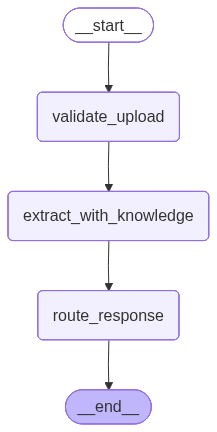

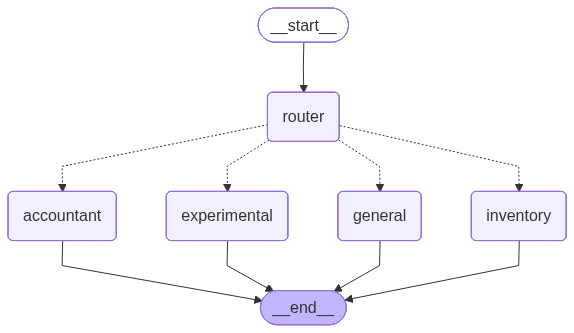

In [76]:
import json
import sys
import types
import uuid
from dataclasses import asdict
from pathlib import Path
from typing import Any, Literal, TypedDict

from langgraph.graph import END, StateGraph


class RouterGraphState(TypedDict, total=False):
    message: str
    history: list[MessageSchema]
    route: Route
    predicted_route: Route
    route_reason: str
    confidence: float
    answer: str
    tokens: list[str]
    usage_events: list[dict[str, Any]]
    error: str
    stream: bool
    system_prompt: str
    file_bytes: bytes
    filename: str
    file_content_type: str
    source_document_type: Literal["auto", "invoice", "receipt"]
    company_id: str
    user_id: str
    knowledge_url: str
    response_type: str
    response_payload: dict[str, Any]
    validated_upload: dict[str, Any]


@dataclass
class CompiledRouterGraph:
    app: Any
    accountant: BaseAgent | None
    inventory: BaseAgent | None
    router_llm: BaseChatModel
    fallback_llm: BaseChatModel


def _state_has_file_upload(state: RouterGraphState) -> bool:
    file_bytes = state.get("file_bytes")
    filename = state.get("filename")
    content_type = state.get("file_content_type")
    return isinstance(file_bytes, (bytes, bytearray)) and bool(file_bytes) and bool(filename) and bool(content_type)


async def _run_subagent(
    runtime: BaseAgent,
    state: RouterGraphState,
    *,
    label: str,
) -> RouterGraphState:
    tokens: list[str] = []
    stream = bool(state.get("stream", False))
    if stream:
        print(f"\n[{label}] streaming:")

    try:
        async for token in runtime.run(state["message"], state.get("history", [])):
            tokens.append(token)
            if stream:
                print(token, end="", flush=True)
    except Exception as exc:
        error_message = f"{label} runtime failed: {exc.__class__.__name__}: {exc}"
        print(f"\n[{label}] ERROR: {error_message}")
        return {
            "answer": "",
            "tokens": tokens,
            "usage_events": [],
            "error": error_message,
        }

    if stream:
        print()
    usage = [asdict(event) for event in runtime.consume_usage_events()]
    return {
        "answer": "".join(tokens),
        "tokens": tokens,
        "usage_events": usage,
    }


def _load_experimental_runner() -> Any:
    notebook_path = Path(REPO_ROOT) / "notebooks" / "experimental_graph_playground.ipynb"
    if not notebook_path.exists():
        raise FileNotFoundError(f"Experimental notebook not found: {notebook_path}")

    payload = json.loads(notebook_path.read_text(encoding="utf-8"))

    # Execute notebook code in an actual module so postponed annotations
    # (e.g. from `from __future__ import annotations`) can resolve symbols
    # like `Any` via `get_type_hints` inside LangGraph.
    module_name = f"_experimental_graph_runtime_{uuid.uuid4().hex}"
    module = types.ModuleType(module_name)
    module.__file__ = str(notebook_path)
    sys.modules[module_name] = module
    scope = module.__dict__

    for cell in payload.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        if source.strip():
            exec(source, scope)

    runner = scope.get("run_experimental_graph_tool")
    if runner is None:
        raise ValueError("run_experimental_graph_tool was not found in experimental notebook")
    return runner


def build_router_graph(
    *,
    accountant: BaseAgent | None,
    inventory: BaseAgent | None,
    router_llm: BaseChatModel,
    fallback_llm: BaseChatModel,
) -> CompiledRouterGraph:
    try:
        experimental_runner = _load_experimental_runner()
    except Exception as exc:
        print(f"[experimental] runner unavailable: {exc}")
        experimental_runner = None

    async def router_node(state: RouterGraphState) -> RouterGraphState:
        if _state_has_file_upload(state):
            chosen: Route = "experimental"
            if experimental_runner is None:
                chosen = "general"
            return {
                "predicted_route": "experimental",
                "route": chosen,
                "route_reason": "File upload detected in state; forcing experimental graph path.",
                "confidence": 1.0,
            }

        prompt = state.get("system_prompt") or DEFAULT_ROUTER_SYSTEM_PROMPT
        decision = await classify_route(
            llm=router_llm,
            message=state["message"],
            history=state.get("history", []),
            system_prompt=prompt,
        )
        chosen = decision.route
        if chosen == "inventory" and inventory is None:
            chosen = "general"
        if chosen == "accountant" and accountant is None:
            chosen = "general"
        if chosen == "experimental" and experimental_runner is None:
            chosen = "general"
        return {
            "predicted_route": decision.route,
            "route": chosen,
            "route_reason": decision.reason,
            "confidence": decision.confidence,
        }

    async def accountant_node(state: RouterGraphState) -> RouterGraphState:
        if accountant is None:
            return {"error": "accountant runtime is not configured", "answer": ""}
        return await _run_subagent(accountant, state, label="accountant")

    async def inventory_node(state: RouterGraphState) -> RouterGraphState:
        if inventory is None:
            return {"error": "inventory runtime is not configured", "answer": ""}
        return await _run_subagent(inventory, state, label="inventory")

    async def experimental_node(state: RouterGraphState) -> RouterGraphState:
        if experimental_runner is None:
            return {"error": "experimental runner is not configured", "answer": ""}

        if not _state_has_file_upload(state):
            return {
                "error": "experimental route requires file_bytes, filename, and file_content_type",
                "answer": "",
            }

        result = await experimental_runner(
            message=state["message"],
            file_bytes=bytes(state["file_bytes"]),
            filename=str(state["filename"]),
            file_content_type=str(state["file_content_type"]),
            company_id=str(state.get("company_id") or ""),
            user_id=str(state.get("user_id") or X_USER_ID),
            knowledge_url=str(state.get("knowledge_url") or "http://localhost:8003"),
            source_document_type=state.get("source_document_type") or "auto",
            history=state.get("history", []),
            stream=bool(state.get("stream", False)),
        )
        return {
            "answer": result.get("answer", ""),
            "tokens": result.get("tokens", []),
            "usage_events": result.get("usage_events", []),
            "response_type": result.get("response_type", "document_review"),
            "response_payload": result.get("response_payload", {}),
            "validated_upload": result.get("validated_upload", {}),
        }

    async def general_node(state: RouterGraphState) -> RouterGraphState:
        history_msgs: list[Any] = []
        for msg in state.get("history", [])[-6:]:
            history_msgs.append(
                HumanMessage(content=msg.content) if msg.role == "user" else SystemMessage(content=msg.content)
            )
        history_msgs.append(HumanMessage(content=state["message"]))
        sys_msg = SystemMessage(
            content=(
                "You are a friendly assistant for a small business platform. "
                "Answer concisely. If the user asks for invoices/expenses/stock, "
                "tell them you'll route to the right specialist next time."
            )
        )
        result = await fallback_llm.ainvoke([sys_msg, *history_msgs])
        text = getattr(result, "content", str(result))
        if state.get("stream"):
            print("\n[general]", text)
        return {"answer": text, "tokens": [text], "usage_events": []}

    def _dispatch(state: RouterGraphState) -> str:
        route = state.get("route", "general")
        return route

    graph = StateGraph(RouterGraphState)
    graph.add_node("router", router_node)
    graph.add_node("accountant", accountant_node)
    graph.add_node("inventory", inventory_node)
    graph.add_node("experimental", experimental_node)
    graph.add_node("general", general_node)

    graph.set_entry_point("router")
    graph.add_conditional_edges(
        "router",
        _dispatch,
        {
            "accountant": "accountant",
            "inventory": "inventory",
            "experimental": "experimental",
            "general": "general",
        },
    )
    graph.add_edge("accountant", END)
    graph.add_edge("inventory", END)
    graph.add_edge("experimental", END)
    graph.add_edge("general", END)

    compiled = graph.compile()
    return CompiledRouterGraph(
        app=compiled,
        accountant=accountant,
        inventory=inventory,
        router_llm=router_llm,
        fallback_llm=fallback_llm,
    )


print("Router graph builder ready.")


def _auto_render_structural_preview() -> None:
    """Show the freshly-compiled graph structure on every build-cell run.

    The renderer (`visualize_compiled_router_graph`) lives in the dedicated
    visualization cell below. The first time you open the notebook, run that
    cell once; every subsequent rerun of THIS cell will re-render the graph
    automatically.
    """
    renderer = globals().get("visualize_compiled_router_graph")
    if renderer is None:
        print(
            "\n[viz] Visualization helper not loaded yet. "
            "Run the '## 6) Visualize the compiled graph' cell once to enable "
            "auto-rendering on subsequent reruns of this cell."
        )
        return

    preview = build_router_graph(
        accountant=None,
        inventory=None,
        router_llm=None,  # type: ignore[arg-type]
        fallback_llm=None,  # type: ignore[arg-type]
    )
    renderer(preview.app, label="router graph (structural preview)")


_auto_render_structural_preview()


## 5) Bring it all together

The async helper below:

1. Connects to MongoDB.
2. Opens an HTTP session shared by both subagents.
3. Loads the configured accountant (and optionally inventory) `AgentInDB`.
4. Builds each specialist runtime.
5. Compiles the LangGraph and returns it together with the session.

`run_router_turn(...)` then drives a single user turn through the compiled
graph and returns the final state plus a small trace dict for inspection.

In [77]:
import asyncio
from datetime import UTC, datetime


async def setup_router_graph(
    *,
    user_id: str = X_USER_ID,
    accountant_agent_id: str = ACCOUNTANT_AGENT_ID,
    inventory_agent_id: str | None = INVENTORY_AGENT_ID or None,
) -> tuple[CompiledRouterGraph, RouterSession]:
    await connect_db()
    session = open_router_session()

    effective_inventory_agent_id = inventory_agent_id
    if not effective_inventory_agent_id:
        effective_inventory_agent_id = await resolve_agent_id_by_type(user_id, "inventory")
        if effective_inventory_agent_id:
            print(f"[setup] Auto-selected inventory agent: {effective_inventory_agent_id}")
        else:
            print("[setup] No inventory agent found for this user; inventory route will fallback to general.")

    accountant_agent = await load_agent(user_id, accountant_agent_id) if accountant_agent_id else None
    inventory_agent = (
        await load_agent(user_id, effective_inventory_agent_id) if effective_inventory_agent_id else None
    )

    accountant_runtime = (
        build_runtime_for(accountant_agent, user_id=user_id, tool_context=session.tool_context)
        if accountant_agent is not None
        else None
    )
    inventory_runtime = (
        build_runtime_for(inventory_agent, user_id=user_id, tool_context=session.tool_context)
        if inventory_agent is not None
        else None
    )

    router_llm = build_router_llm()
    fallback_llm = build_router_llm(temperature=0.3)

    compiled = build_router_graph(
        accountant=accountant_runtime,
        inventory=inventory_runtime,
        router_llm=router_llm,
        fallback_llm=fallback_llm,
    )
    return compiled, session


async def teardown_router_graph(session: RouterSession) -> None:
    try:
        await session.aclose()
    finally:
        close_db()


def _ensure_running_loop():
    try:
        loop = asyncio.get_running_loop()
    except RuntimeError:
        return None
    return loop


def run_async(coro):
    loop = _ensure_running_loop()
    if loop and loop.is_running():
        try:
            import nest_asyncio  # type: ignore
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "nest-asyncio>=1.6.0"])
            import nest_asyncio  # type: ignore
        nest_asyncio.apply()
        return loop.run_until_complete(coro)
    return asyncio.run(coro)


async def run_router_turn(
    compiled: CompiledRouterGraph,
    *,
    message: str,
    history: list[MessageSchema] | None = None,
    stream: bool = True,
    system_prompt: str | None = None,
    file_bytes: bytes | None = None,
    filename: str | None = None,
    file_content_type: str | None = None,
    source_document_type: Literal["auto", "invoice", "receipt"] = "auto",
    company_id: str | None = None,
    user_id: str | None = None,
    knowledge_url: str = "http://localhost:8003",
) -> dict[str, Any]:
    history = history or []
    initial: RouterGraphState = {
        "message": message,
        "history": history,
        "stream": stream,
        "system_prompt": system_prompt or DEFAULT_ROUTER_SYSTEM_PROMPT,
    }
    if file_bytes is not None and filename and file_content_type:
        initial["file_bytes"] = file_bytes
        initial["filename"] = filename
        initial["file_content_type"] = file_content_type
        initial["source_document_type"] = source_document_type
        if company_id:
            initial["company_id"] = company_id
        if user_id:
            initial["user_id"] = user_id
        initial["knowledge_url"] = knowledge_url

    final_state: RouterGraphState = await compiled.app.ainvoke(initial)
    return {
        "predicted_route": final_state.get("predicted_route"),
        "route": final_state.get("route"),
        "route_reason": final_state.get("route_reason"),
        "confidence": final_state.get("confidence"),
        "answer": final_state.get("answer", ""),
        "usage_events": final_state.get("usage_events", []),
        "response_type": final_state.get("response_type"),
        "response_payload": final_state.get("response_payload"),
        "validated_upload": final_state.get("validated_upload"),
        "error": final_state.get("error"),
    }


def append_turn(history: list[MessageSchema], user_message: str, assistant_message: str) -> list[MessageSchema]:
    now = datetime.now(UTC)
    history.append(MessageSchema(role="user", content=user_message, created_at=now))
    history.append(MessageSchema(role="assistant", content=assistant_message, created_at=now))
    return history


print("Setup helpers ready.")


Setup helpers ready.


## 6) Visualize the compiled graph

This cell keeps visualization minimal: it renders only the graph image (the
same style as your screenshot).

It still defines `visualize_compiled_router_graph(...)` as a separate reusable
helper, and the build cell above can call it automatically on reruns.

Experimental graph helpers ready.


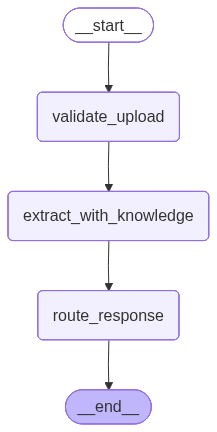

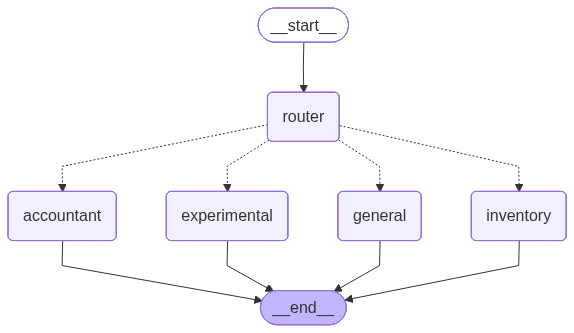

In [78]:
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = print


def visualize_compiled_router_graph(compiled_app: Any, *, label: str = "router graph") -> None:
    """Render only the inline graph image."""
    graph = compiled_app.get_graph()

    if Image is None:
        print(f"[{label}] IPython image display is unavailable in this environment.")
        return

    try:
        png_bytes = graph.draw_mermaid_png()
        display(Image(png_bytes))
    except Exception as exc:
        print(f"[{label}] Inline PNG not available ({exc.__class__.__name__}: {exc}).")
        print("Install renderer deps or use graph.draw_mermaid() as fallback.")


def build_router_graph_preview() -> Any:
    """Compile a structural-only router graph (no DB / no API calls).

    `build_router_graph` captures the LLM/runtime references in node closures,
    but `compile()` never invokes them, so passing `None` is safe and lets us
    visualize the topology without any external dependency.
    """
    preview = build_router_graph(
        accountant=None,
        inventory=None,
        router_llm=None,  # type: ignore[arg-type]
        fallback_llm=None,  # type: ignore[arg-type]
    )
    return preview.app


visualize_compiled_router_graph(
    build_router_graph_preview(),
    label="router graph (structural preview)",
)


## 7) Run a single turn through the graph

The first run will:
1. Build/connect resources.
2. Classify the message via the router.
3. Stream the chosen specialist's answer.
4. Tear down all sessions cleanly.

Edit `USER_MESSAGE` and rerun this cell to iterate. `SESSION_HISTORY` keeps
multi-turn context so confirmation flows ("yes, create it") can be tested.

Experimental graph helpers ready.


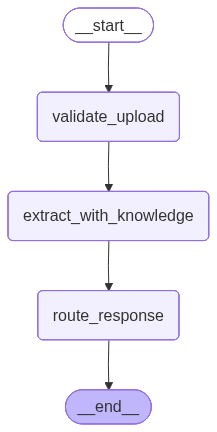


Predicted   : experimental
Executed    : experimental
Confidence  : 1.0
Reason      : User explicitly requests to run the experimental graph test flow.
Error       : experimental route requires file_bytes, filename, and file_content_type
Final answer:
(empty)

Session history length: 16 messages


/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='exp... flow.', confidence=1.0), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(


In [79]:
SESSION_HISTORY: list[MessageSchema] = globals().get("SESSION_HISTORY", [])

USER_MESSAGE = "Please run the experimental graph test flow"


async def _run_once(message: str, history: list[MessageSchema]) -> dict[str, Any]:
    compiled, session = await setup_router_graph()
    try:
        result = await run_router_turn(compiled, message=message, history=history, stream=True)
    finally:
        await teardown_router_graph(session)
    return result


result = run_async(_run_once(USER_MESSAGE, SESSION_HISTORY))

print("\n" + "=" * 110)
print(f"Predicted   : {result['predicted_route']}")
print(f"Executed    : {result['route']}")
print(f"Confidence  : {result['confidence']}")
print(f"Reason      : {result['route_reason']}")
if result.get("predicted_route") != result.get("route"):
    print("Fallback    : Specialist runtime unavailable; route downgraded to general")
if result.get("error"):
    print(f"Error       : {result['error']}")
print("=" * 110)
print("Final answer:")
print(result["answer"] or "(empty)")

if result["answer"]:
    append_turn(SESSION_HISTORY, USER_MESSAGE, result["answer"])
print(f"\nSession history length: {len(SESSION_HISTORY)} messages")


Experimental graph helpers ready.


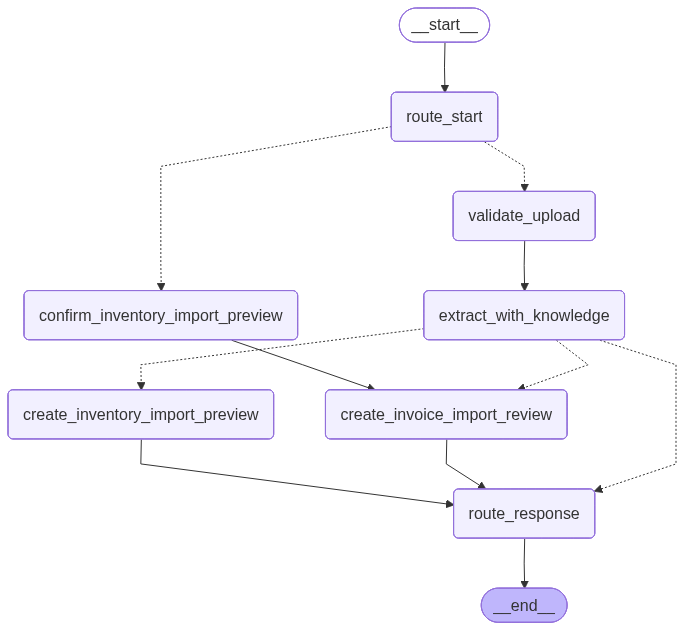

[experimental/validate] filename=Invoice-5X3FU86U-0006.pdf content_type=application/pdf bytes=312615
[experimental/knowledge] provider=openai model=gpt-4.1-mini
[experimental/inventory-preview] preview_id=69ff5792b964ca376eeb8b8f lines=5
[experimental] invoice items were extracted and converted to an inventory import preview. Render the preview form for user approval before confirming.

Predicted   : experimental
Executed    : experimental
Confidence  : 1.0
Reason      : File upload detected in state; forcing experimental graph path.
Response type: expense_inventory_intake
Validated upload: {'filename': 'Invoice-5X3FU86U-0006.pdf', 'content_type': 'application/pdf', 'size_bytes': 312615}
Final answer:
[experimental] invoice items were extracted and converted to an inventory import preview. Render the preview form for user approval before confirming.

Response payload keys: ['approval_action', 'document', 'draft', 'extracted_at', 'extracted_text', 'inventory_import_preview', 'model', 'p

In [84]:
from pathlib import Path
import mimetypes

SESSION_HISTORY = globals().get("SESSION_HISTORY", [])

USER_MESSAGE = "Process this uploaded document"
FILE_PATH = "/Users/valentinbarakov/Downloads/Invoice-5X3FU86U-0006.pdf"  # update this
COMPANY_ID = "69ee334437c7ac857d865c89"  # required for knowledge extraction
SOURCE_DOCUMENT_TYPE: Literal["auto", "invoice", "receipt"] = "auto"


async def _run_file_upload_once(message: str, history: list[MessageSchema]) -> dict[str, Any]:
    path = Path(FILE_PATH)
    if not path.exists() or not path.is_file():
        raise FileNotFoundError(f"File not found: {path}")

    file_bytes = path.read_bytes()
    file_content_type = (mimetypes.guess_type(path.name)[0] or "application/octet-stream").lower()

    import inspect

    signature = inspect.signature(run_router_turn)
    if "file_bytes" not in signature.parameters:
        raise RuntimeError(
            "Your kernel has an older run_router_turn() definition. "
            "Rerun the router helper/build cells (sections 4 and 5), then run this cell again."
        )

    compiled, session = await setup_router_graph()
    try:
        result = await run_router_turn(
            compiled,
            message=message,
            history=history,
            stream=True,
            file_bytes=file_bytes,
            filename=path.name,
            file_content_type=file_content_type,
            source_document_type=SOURCE_DOCUMENT_TYPE,
            company_id=COMPANY_ID,
            user_id=X_USER_ID,
            knowledge_url="http://localhost:8003",
        )
    finally:
        await teardown_router_graph(session)
    return result


if not COMPANY_ID.strip():
    raise ValueError("Set COMPANY_ID before running this cell.")

result = run_async(_run_file_upload_once(USER_MESSAGE, SESSION_HISTORY))

print("\n" + "=" * 110)
print(f"Predicted   : {result['predicted_route']}")
print(f"Executed    : {result['route']}")
print(f"Confidence  : {result['confidence']}")
print(f"Reason      : {result['route_reason']}")
if result.get("error"):
    print(f"Error       : {result['error']}")
print("=" * 110)
print("Response type:", result.get("response_type"))
print("Validated upload:", result.get("validated_upload"))
print("Final answer:")
print(result.get("answer") or "(empty)")

response_payload = result.get("response_payload") or {}
if response_payload:
    print("\nResponse payload keys:", sorted(response_payload.keys()))
    
if result.get("answer"):
    append_turn(SESSION_HISTORY, USER_MESSAGE, result["answer"])
print(f"\nSession history length: {len(SESSION_HISTORY)} messages")


## 8) Evaluation harness for tuning the router

Add labelled cases to `ROUTER_EVAL_CASES` and run this cell to score routing
accuracy. To keep evaluation cheap, the harness only runs the **router node**
by default — it does not invoke the specialist runtime, so each case costs
exactly one small LLM call.

Set `EXECUTE_SPECIALIST=True` to also run the chosen subagent end-to-end on
each case (slow, hits the database/business service).

In [81]:
ROUTER_EVAL_CASES: list[dict[str, Any]] = [
    {"message": "Show me last month's invoices over 1000 BGN", "expected": "accountant"},
    {"message": "Record an expense: office chairs, 450 BGN, paid today", "expected": "accountant"},
    {"message": "What's the VAT registration threshold in Bulgaria right now?", "expected": "accountant"},
    {"message": "Find Contoso EOOD in the Bulgarian company registry", "expected": "accountant"},
    {"message": "How many iPhones do we have left in the Sofia warehouse?", "expected": "inventory"},
    {"message": "Mark a stock-out movement: 5 items SKU-1234 from main warehouse", "expected": "inventory"},
    {"message": "Which items are below their reorder point?", "expected": "inventory"},
    {"message": "Show me the import preview for last week's supplier delivery", "expected": "inventory"},
    {"message": "Please run the experimental graph test flow", "expected": "experimental"},
    {"message": "Hi, what can this app do?", "expected": "general"},
    {"message": "Thanks!", "expected": "general"},
    {"message": "yes, create it", "expected": "accountant", "history_hint": "accountant_invoice_draft"},
]

EXECUTE_SPECIALIST = False


def _hint_history(hint: str | None) -> list[MessageSchema]:
    if hint == "accountant_invoice_draft":
        now = datetime.now(UTC)
        return [
            MessageSchema(role="user", content="Create an invoice to Contoso for 1500 EUR.", created_at=now),
            MessageSchema(
                role="assistant",
                content=(
                    "Here is the draft invoice for Contoso, 1500 EUR for software services. "
                    "Reply 'yes' to confirm and I'll create it."
                ),
                created_at=now,
            ),
        ]
    return []


async def _evaluate_router_only(cases: list[dict[str, Any]]) -> list[dict[str, Any]]:
    await connect_db()
    session = open_router_session()
    try:
        router_llm = build_router_llm()
        rows: list[dict[str, Any]] = []
        for case in cases:
            history = _hint_history(case.get("history_hint"))
            decision = await classify_route(
                llm=router_llm,
                message=case["message"],
                history=history,
            )
            rows.append(
                {
                    "message": case["message"],
                    "expected": case["expected"],
                    "predicted": decision.route,
                    "confidence": decision.confidence,
                    "reason": decision.reason,
                    "ok": decision.route == case["expected"],
                }
            )
        return rows
    finally:
        await session.aclose()
        close_db()


async def _evaluate_full(cases: list[dict[str, Any]]) -> list[dict[str, Any]]:
    compiled, session = await setup_router_graph()
    try:
        rows: list[dict[str, Any]] = []
        for case in cases:
            history = _hint_history(case.get("history_hint"))
            result = await run_router_turn(
                compiled,
                message=case["message"],
                history=history,
                stream=False,
            )
            rows.append(
                {
                    "message": case["message"],
                    "expected": case["expected"],
                    "predicted": result["route"],
                    "confidence": result.get("confidence"),
                    "reason": result.get("route_reason"),
                    "answer_chars": len(result.get("answer") or ""),
                    "ok": result["route"] == case["expected"],
                }
            )
        return rows
    finally:
        await teardown_router_graph(session)


def _print_eval_table(rows: list[dict[str, Any]]) -> None:
    correct = sum(1 for r in rows if r["ok"])
    total = len(rows)
    print(f"Router accuracy: {correct}/{total} = {correct / total:.0%}")
    print("=" * 110)
    for row in rows:
        marker = "OK " if row["ok"] else "FAIL"
        conf = row.get("confidence")
        conf_text = f"{conf:.2f}" if isinstance(conf, (int, float)) else "n/a"
        print(
            f"[{marker}] expected={row['expected']:10} got={row['predicted']:10} "
            f"conf={conf_text} :: {row['message']}"
        )
        if not row["ok"]:
            print(f"      reason: {row['reason']}")


eval_rows = run_async(
    _evaluate_full(ROUTER_EVAL_CASES) if EXECUTE_SPECIALIST else _evaluate_router_only(ROUTER_EVAL_CASES)
)
_print_eval_table(eval_rows)


/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...ents.', confidence=0.95), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...asks.', confidence=0.95), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route=

Router accuracy: 12/12 = 100%
[OK ] expected=accountant got=accountant conf=0.95 :: Show me last month's invoices over 1000 BGN
[OK ] expected=accountant got=accountant conf=0.95 :: Record an expense: office chairs, 450 BGN, paid today
[OK ] expected=accountant got=accountant conf=0.95 :: What's the VAT registration threshold in Bulgaria right now?
[OK ] expected=accountant got=accountant conf=0.90 :: Find Contoso EOOD in the Bulgarian company registry
[OK ] expected=inventory  got=inventory  conf=0.95 :: How many iPhones do we have left in the Sofia warehouse?
[OK ] expected=inventory  got=inventory  conf=0.95 :: Mark a stock-out movement: 5 items SKU-1234 from main warehouse
[OK ] expected=inventory  got=inventory  conf=0.95 :: Which items are below their reorder point?
[OK ] expected=inventory  got=inventory  conf=0.90 :: Show me the import preview for last week's supplier delivery
[OK ] expected=experimental got=experimental conf=1.00 :: Please run the experimental graph test flow


/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...ting.', confidence=0.95), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(


## 9) Router prompt tuning

Compare two or more router prompts side-by-side over the eval set. The cheapest
way to iterate: clone `DEFAULT_ROUTER_SYSTEM_PROMPT`, tweak the rules, add a
new entry to `ROUTER_VARIANTS`, and rerun this cell.

The harness reuses the router-only evaluation (no specialist call), so each
variant costs roughly `len(ROUTER_EVAL_CASES)` small LLM calls.

In [82]:
STRICT_VARIANT = """You are a strict router. Pick exactly one of: accountant, inventory, experimental, general.

- accountant: anything mentioning money, invoices, expenses, partners, VAT, tax,
  CompanyBook, financial summaries, accounting periods.
- inventory: anything mentioning stock, items, locations, warehouses, reorder
  points, supplier import previews, "how many X", warehouse movements.
- experimental: requests to run/test/demo/prototype the experimental graph or
  playground-only experimental flow.
- general: greetings, app help, definitions, ambiguous chit-chat.

Hard rules:
- "yes/ok/да" -> route to whichever specialist authored the most recent draft.
- Money words ALWAYS beat stock words ("invoice for stock items" -> accountant).
- Explicit experimental graph testing requests -> experimental.
- If neither domain word appears, default to general.
"""

KEYWORD_VARIANT = """Routing rules (return one of: accountant | inventory | experimental | general).

Score the latest user message:
+1 to accountant for each of: invoice, expense, VAT, tax, partner, payment,
   payroll, balance, currency, BGN, EUR, CompanyBook, ЕИК, фактура, разход.
+1 to inventory for each of: stock, item, SKU, warehouse, location, reorder,
   import preview, supplier delivery, how many, склад, наличност.
+1 to experimental for each of: experimental, prototype, test graph, graph test,
   playground experiment, demo graph.

Pick the higher score. Tie -> general. Confirmation replies inherit the route
of the most recent assistant message.
"""

ROUTER_VARIANTS: dict[str, str] = {
    "default": DEFAULT_ROUTER_SYSTEM_PROMPT,
    "strict": STRICT_VARIANT,
    "keyword": KEYWORD_VARIANT,
}


async def _evaluate_variant(name: str, prompt: str, cases: list[dict[str, Any]]) -> dict[str, Any]:
    await connect_db()
    try:
        router_llm = build_router_llm()
        rows: list[dict[str, Any]] = []
        for case in cases:
            history = _hint_history(case.get("history_hint"))
            decision = await classify_route(
                llm=router_llm,
                message=case["message"],
                history=history,
                system_prompt=prompt,
            )
            rows.append(
                {
                    "message": case["message"],
                    "expected": case["expected"],
                    "predicted": decision.route,
                    "ok": decision.route == case["expected"],
                }
            )
        correct = sum(1 for r in rows if r["ok"])
        return {"variant": name, "accuracy": correct / len(rows), "rows": rows}
    finally:
        close_db()


async def _compare_variants() -> list[dict[str, Any]]:
    results = []
    for name, prompt in ROUTER_VARIANTS.items():
        result = await _evaluate_variant(name, prompt, ROUTER_EVAL_CASES)
        results.append(result)
    return results


comparison = run_async(_compare_variants())

print("Router prompt comparison")
print("=" * 110)
for entry in comparison:
    print(f"{entry['variant']:10} accuracy={entry['accuracy']:.0%}")

print("\nPer-case predictions")
print("=" * 110)
header = f"{'message':70} {'expect':10} " + " ".join(f"{name:10}" for name in ROUTER_VARIANTS)
print(header)
for idx, case in enumerate(ROUTER_EVAL_CASES):
    msg = case["message"]
    if len(msg) > 68:
        msg = msg[:65] + "..."
    cells = []
    for entry in comparison:
        row = entry["rows"][idx]
        cell = row["predicted"] if row["ok"] else f"!{row['predicted']}"
        cells.append(f"{cell:10}")
    print(f"{msg:70} {case['expected']:10} " + " ".join(cells))


/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...ents.', confidence=0.95), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...ping.', confidence=0.95), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(
/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route=

Router prompt comparison
default    accuracy=100%
strict     accuracy=92%
keyword    accuracy=100%

Per-case predictions
message                                                                expect     default    strict     keyword   
Show me last month's invoices over 1000 BGN                            accountant accountant accountant accountant
Record an expense: office chairs, 450 BGN, paid today                  accountant accountant accountant accountant
What's the VAT registration threshold in Bulgaria right now?           accountant accountant accountant accountant
Find Contoso EOOD in the Bulgarian company registry                    accountant accountant !general   accountant
How many iPhones do we have left in the Sofia warehouse?               inventory  inventory  inventory  inventory 
Mark a stock-out movement: 5 items SKU-1234 from main warehouse        inventory  inventory  inventory  inventory 
Which items are below their reorder point?                             inv

/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=RouterDecision(route='acc...tasks.', confidence=0.9), input_type=RouterDecision])
  return self.__pydantic_serializer__.to_python(


## Next steps for productionization

When the routing prompt is good enough on this notebook, the rough plan to
land it in `services/agent` is:

1. Move `RouterDecision` + `classify_route` into
   `services/agent/app/runtime/router.py` (or similar) and unit-test it like
   the existing tool tests.
2. Introduce a new `agent_type = "router"` (or a separate top-level
   `RouterRuntime`) that owns child runtimes built via `create_agent_runtime`.
3. Reuse the same `BaseAgent.run(...)` contract on the router runtime so
   `chat_service` / SSE streaming works without any frontend changes.
4. Persist the routing decision in conversation metadata so it shows up in the
   chat UI (helpful for debugging mis-routes in production).
5. Add LangGraph (`langgraph>=0.2`) to `services/agent/requirements.txt`
   alongside the new module.

Until then, keep iterating in this notebook — every change to the production
runtime files is picked up immediately because the imports above point at the
real `services/agent/app/...` modules.